
# EDA & Baseline de Fraude — v2 (PaySim)

> Gerado em 2025-09-27 21:58  
> **Objetivo:** Notebook **didático** com melhorias para EDA, *feature engineering* e seleção de *threshold* (com custo por `amount`), exportando relatório **YAML**.

**Melhorias**
- `DATA_PATH` via env var.
- Features de domínio (deltas/erros de balanço, razões com saldo, logs, flags merchant/zero).
- `day`/`hour` a partir de `step`.
- Cadeia **TRANSFER→CASH_OUT (≤48h)**.
- Avaliação com **PR AUC** e **ROC AUC**.
- Threshold para **Precision ≥ alvo** e **threshold por custo** (ponderado por `amount`).
- Thresholds **segmentados por faixas de valor**.
- Exporta `/mnt/data/fraud_model_report.yaml` e `/mnt/data/top_false_negatives.csv`.



## 0) Preparação

```bash
pip install pandas numpy matplotlib scikit-learn pyyaml
```
Defina `DATA_PATH` ou coloque o CSV no mesmo diretório.


In [1]:

import os, gc, math, warnings, yaml
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, precision_recall_curve, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:

DATA_PATH = os.environ.get("DATA_PATH", "AIMLDataset.csv")

DTYPES = {
    "step": "int32",
    "type": "category",
    "amount": "float32",
    "nameOrig": "category",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "nameDest": "category",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}


In [3]:

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, dtype=DTYPES)
    using_sample = False
else:
    print(f"Aviso: arquivo '{DATA_PATH}' não encontrado. Usando amostra embutida.")
    df = df_sample.copy()
    using_sample = True

print("Shape:", df.shape)
display(df.head(3))


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6396",C1231006815,"170,136.0000","160,296.3594",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7207",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0


In [4]:

print(df.dtypes)
print("\nNulos por coluna:")
print(df.isna().sum())
print("\nDuplicatas:", df.duplicated().sum())
display(df.select_dtypes(include=[np.number]).describe())


step                 int32
type              category
amount             float32
nameOrig          category
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest          category
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object

Nulos por coluna:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicatas: 0


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000"
mean,243.3972,"179,861.8906","833,883.1250","855,113.6250","1,100,701.7500","1,224,996.3750",0.0013,0.0000
std,142.3320,"603,858.2500","2,888,242.7500","2,924,048.5000","3,399,180.2500","3,674,129.0000",0.0359,0.0016
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,156.0000,"13,389.5703",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,239.0000,"74,871.9375","14,208.0000",0.0000,"132,705.6641","214,661.4453",0.0000,0.0000
75%,335.0000,"208,721.4805","107,315.1758","144,258.4062","943,036.6875","1,111,909.2188",0.0000,0.0000
max,743.0000,"92,445,520.0000","59,585,040.0000","49,585,040.0000","356,015,904.0000","356,179,264.0000",1.0000,1.0000


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


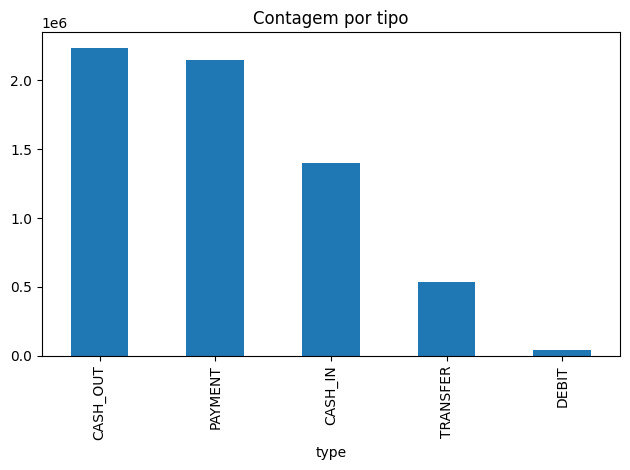

Fraudes: 8,213 / 6,362,620 (0.1291%)


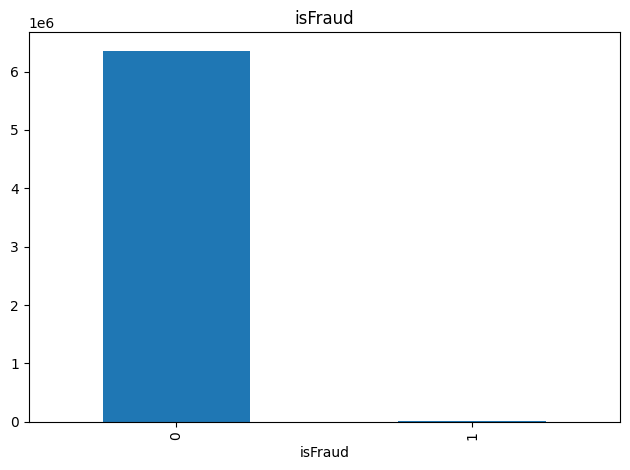

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


,n,fraudes,taxa_fraude
type,,,
TRANSFER,532909,4097,0.0077
CASH_OUT,2237500,4116,0.0018
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


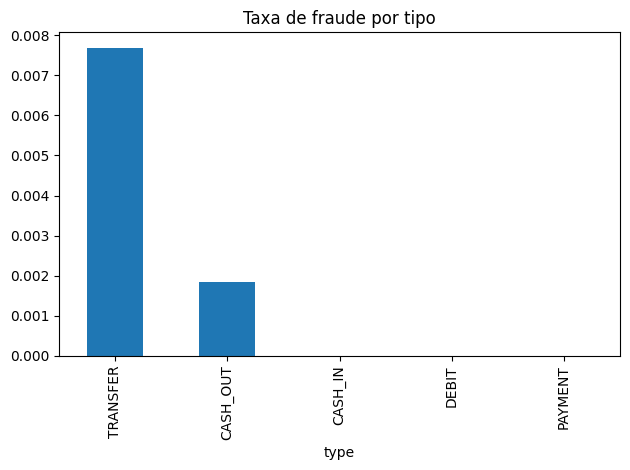

In [5]:

if "type" in df.columns:
    print(df["type"].value_counts())
    plt.figure(); df["type"].value_counts().sort_values(ascending=False).plot(kind="bar"); plt.title("Contagem por tipo"); plt.tight_layout(); plt.show()

if "isFraud" in df.columns:
    total = len(df); frauds = int(df["isFraud"].sum()); rate = (frauds/total*100) if total else 0.0
    print(f"Fraudes: {frauds:,} / {total:,} ({rate:.4f}%)")
    plt.figure(); df["isFraud"].value_counts().sort_index().plot(kind="bar"); plt.title("isFraud"); plt.tight_layout(); plt.show()

if "type" in df.columns and "isFraud" in df.columns:
    xt = pd.crosstab(df["type"], df["isFraud"]); display(xt)
    grp = df.groupby("type")["isFraud"].agg(["count","sum","mean"]).rename(columns={"count":"n","sum":"fraudes","mean":"taxa_fraude"})
    display(grp.sort_values("taxa_fraude", ascending=False))
    plt.figure(); grp["taxa_fraude"].sort_values(ascending=False).plot(kind="bar"); plt.title("Taxa de fraude por tipo"); plt.tight_layout(); plt.show()


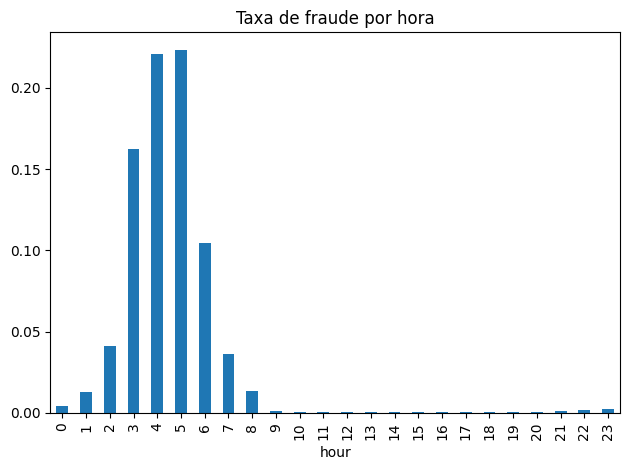

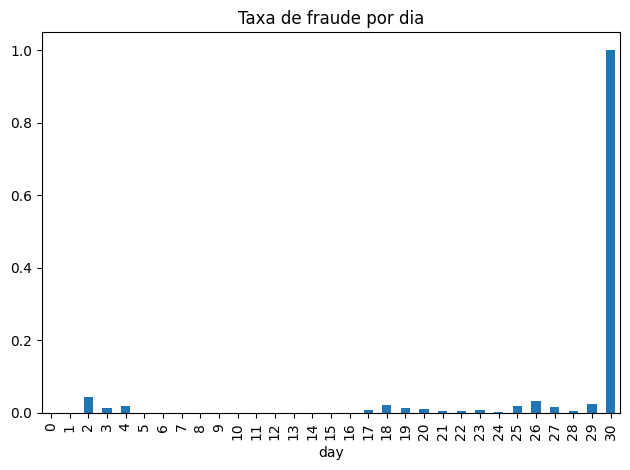

In [6]:

if "step" in df.columns:
    df["day"] = (df["step"] // 24).astype("int16")
    df["hour"] = (df["step"] % 24).astype("int8")
    if "isFraud" in df.columns:
        plt.figure(); df.groupby("hour")["isFraud"].mean().plot(kind="bar"); plt.title("Taxa de fraude por hora"); plt.tight_layout(); plt.show()
        plt.figure(); df.groupby("day")["isFraud"].mean().plot(kind="bar"); plt.title("Taxa de fraude por dia"); plt.tight_layout(); plt.show()


In [7]:

for col in ["nameOrig","nameDest"]:
    if str(df[col].dtype) == "category":
        df[col] = df[col].astype("string")

df["orig_is_merchant"] = df["nameOrig"].str.startswith("M").fillna(False).astype("int8")
df["dest_is_merchant"] = df["nameDest"].str.startswith("M").fillna(False).astype("int8")

for col in ["oldbalanceOrg","newbalanceOrg","oldbalanceDest","newbalanceDest","amount"]:
    if col not in df.columns:
        df[col] = 0.0

df["orig_change"] = (df["newbalanceOrig"] - df["oldbalanceOrg"]).astype("float32")
df["dest_change"] = (df["newbalanceDest"] - df["oldbalanceDest"]).astype("float32")

outflow = {"CASH_OUT","TRANSFER","DEBIT","PAYMENT"}
inflow  = {"CASH_IN"}
def _sorig(t): return -1.0 if t in outflow else (1.0 if t in inflow else 0.0)
def _sdest(t): return  1.0
sign_o = df["type"].astype("string").map(_sorig).fillna(0.0)
sign_d = df["type"].astype("string").map(_sdest).fillna(0.0)

df["errorBalanceOrig"] = (df["oldbalanceOrg"] + sign_o * df["amount"] - df["newbalanceOrig"]).abs().astype("float32")
df["errorBalanceDest"] = (df["newbalanceDest"] - (df["oldbalanceDest"] + sign_d * df["amount"])).abs().astype("float32")

eps = 1e-3
df["log_amount"] = np.log1p(df["amount"]).astype("float32")
df["amount_over_oldOrg"] = (df["amount"] / (df["oldbalanceOrg"] + eps)).astype("float32")
df["amount_over_oldDest"] = (df["amount"] / (df["oldbalanceDest"] + eps)).astype("float32")

df["orig_balances_zero"] = ((df["oldbalanceOrg"]==0) & (df["newbalanceOrig"]==0)).astype("int8")
df["dest_balances_zero"] = ((df["oldbalanceDest"]==0) & (df["newbalanceDest"]==0)).astype("int8")

df["type_code"] = df["type"].cat.codes.astype("int8")


In [8]:

df["is_transfer"] = (df["type"].astype("string") == "TRANSFER").astype("int8")
df["is_cashout"]  = (df["type"].astype("string") == "CASH_OUT").astype("int8")

cashout_first = (df[df["is_cashout"]==1]
                 .sort_values(["nameOrig","step"])
                 .drop_duplicates(["nameOrig"])[["nameOrig","step"]]
                 .rename(columns={"nameOrig":"who","step":"first_cashout_step"}))

transfer_df = df[df["is_transfer"]==1][["step","nameDest"]].copy()
transfer_df = transfer_df.rename(columns={"nameDest":"who","step":"transfer_step"})
transfer_df = transfer_df.merge(cashout_first, on="who", how="left")
transfer_df["cashout_in_48h"] = ((transfer_df["first_cashout_step"] - transfer_df["transfer_step"]) <= 48).astype("int8").fillna(0)

df["transfer_to_cashout_48h"] = 0
df.loc[transfer_df.index, "transfer_to_cashout_48h"] = transfer_df["cashout_in_48h"].values
df["transfer_to_cashout_48h"] = df["transfer_to_cashout_48h"].astype("int8")


In [9]:

if "isFlaggedFraud" in df.columns and "isFraud" in df.columns:
    cm = pd.crosstab(df["isFlaggedFraud"], df["isFraud"])
    display(cm)


isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


Train: (2063665, 14)  Test: (706744, 14)
[LogisticRegression] ROC AUC: 0.9815 | PR AUC: 0.6347


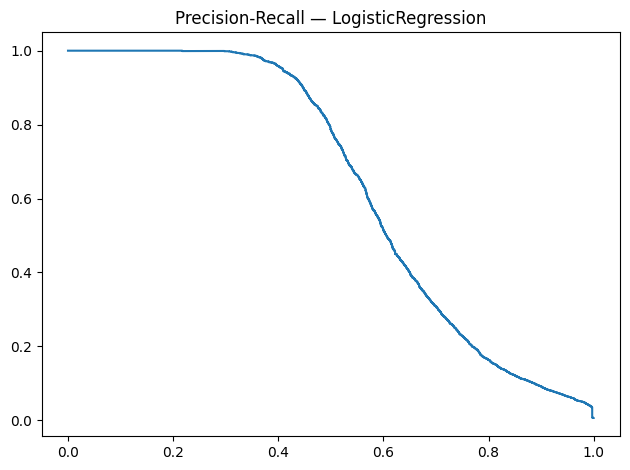

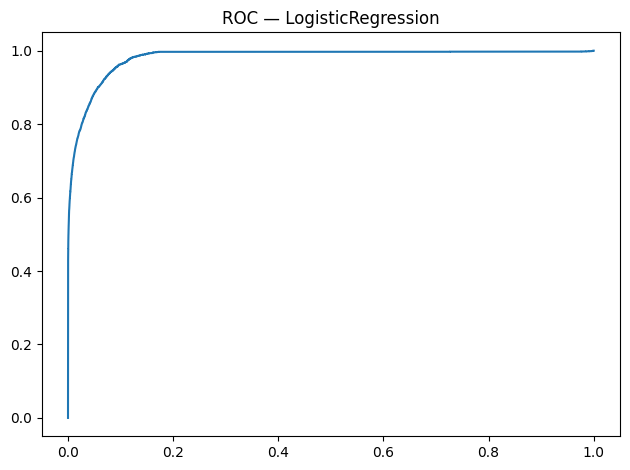

[RandomForest] ROC AUC: 1.0000 | PR AUC: 1.0000


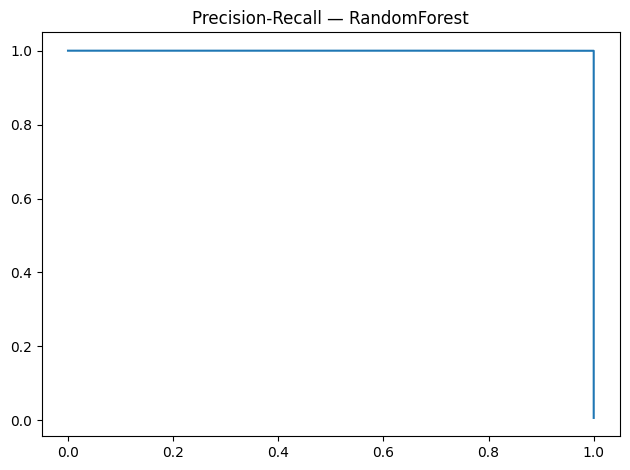

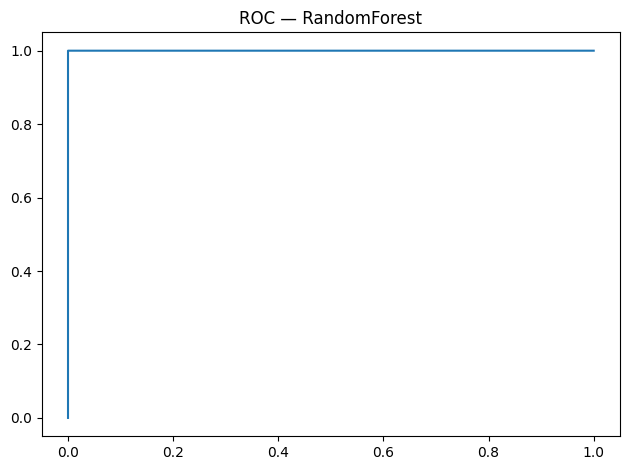

In [10]:

FOCUS_TYPES = {"TRANSFER","CASH_OUT"}

df_model = df.copy()
df_model["type_str"] = df_model["type"].astype("string")
df_model = df_model[df_model["type_str"].isin(list(FOCUS_TYPES)) | (df_model["isFraud"]==1)].copy()
df_model.drop(columns=["type_str"], inplace=True)

FEATURES = [
    "amount","log_amount","amount_over_oldOrg","amount_over_oldDest",
    "orig_balances_zero","dest_balances_zero",
    "errorBalanceOrig","errorBalanceDest",
    "dest_is_merchant","orig_is_merchant",
    "type_code","hour","day",
    "transfer_to_cashout_48h"
]
FEATURES = [f for f in FEATURES if f in df_model.columns]

if "step" in df_model.columns and len(df_model) > 0:
    thr = int(df_model["step"].quantile(0.75))
    train_mask = df_model["step"] < thr
else:
    train_mask = np.random.rand(len(df_model)) < 0.75

X = df_model[FEATURES].fillna(0)
y = df_model["isFraud"].astype(int)
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Train:", X_train.shape, " Test:", X_test.shape)

logreg = LogisticRegression(max_iter=300, class_weight="balanced")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_split=10, min_samples_leaf=2,
    n_jobs=-1, class_weight="balanced_subsample", random_state=42
)
logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:,1]
proba_rf = rf.predict_proba(X_test)[:,1]

def eval_scores(y_true, scores, name):
    roc = roc_auc_score(y_true, scores)
    pr  = average_precision_score(y_true, scores)
    print(f"[{name}] ROC AUC: {roc:.4f} | PR AUC: {pr:.4f}")
    prec, rec, thr = precision_recall_curve(y_true, scores)
    plt.figure(); plt.plot(rec, prec); plt.title(f"Precision-Recall — {name}"); plt.tight_layout(); plt.show()
    fpr, tpr, thr2 = roc_curve(y_true, scores)
    plt.figure(); plt.plot(fpr, tpr); plt.title(f"ROC — {name}"); plt.tight_layout(); plt.show()

eval_scores(y_test, proba_lr, "LogisticRegression")
eval_scores(y_test, proba_rf, "RandomForest")


In [11]:

def threshold_for_min_precision(y_true, scores, min_precision=0.90):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    best_t, best_rec = 0.5, 0.0
    for p, r, t in zip(prec[:-1], rec[:-1], thr):
        if p >= min_precision and r > best_rec:
            best_rec, best_t = r, t
    return float(best_t), float(best_rec)

def cost_at_threshold(y_true, scores, amounts, t, cost_fn=1.0, cost_fp=0.02):
    preds = (scores >= t).astype(int)
    FN = ((y_true==1) & (preds==0))
    FP = ((y_true==0) & (preds==1))
    cost = (amounts[FN].sum() * cost_fn) + (amounts[FP].sum() * cost_fp)
    return float(cost), int(FN.sum()), int(FP.sum())

def best_threshold_by_cost(y_true, scores, amounts, grid_size=200, cost_fn=1.0, cost_fp=0.02):
    qs = np.linspace(0.0, 1.0, grid_size+2)[1:-1]
    cand = np.quantile(scores, qs)
    best = {"t":0.5, "cost":float("inf"), "FN":None, "FP":None}
    for t in np.unique(cand):
        c, fn, fp = cost_at_threshold(y_true, scores, amounts, t, cost_fn, cost_fp)
        if c < best["cost"]:
            best.update({"t":float(t), "cost":float(c), "FN":fn, "FP":fp})
    return best

TARGET_PREC = 0.90
t_lr, rec_lr = threshold_for_min_precision(y_test, proba_lr, TARGET_PREC)
t_rf, rec_rf = threshold_for_min_precision(y_test, proba_rf, TARGET_PREC)
print(f"[LR] threshold p>={TARGET_PREC:.0%} → t={t_lr:.4f} (recall≈{rec_lr:.4f})")
print(f"[RF] threshold p>={TARGET_PREC:.0%} → t={t_rf:.4f} (recall≈{rec_rf:.4f})")

COST_FN, COST_FP = 1.0, 0.02
amounts_test = df_model.loc[~train_mask, "amount"].astype("float32")
best_cost_lr = best_threshold_by_cost(y_test.values, proba_lr, amounts_test.values, cost_fn=COST_FN, cost_fp=COST_FP)
best_cost_rf = best_threshold_by_cost(y_test.values, proba_rf, amounts_test.values, cost_fn=COST_FN, cost_fp=COST_FP)
print("\nMelhor threshold por custo (LR):", best_cost_lr)
print("Melhor threshold por custo (RF):", best_cost_rf)


[LR] threshold p>=90% → t=0.9999 (recall≈0.4476)
[RF] threshold p>=90% → t=0.0431 (recall≈1.0000)

Melhor threshold por custo (LR): {'t': 0.67189817578965, 'cost': 206128288.0, 'FN': 926, 'FP': 17537}
Melhor threshold por custo (RF): {'t': 0.039629426124881406, 'cost': 3207343.25, 'FN': 0, 'FP': 2600}


In [12]:

def thresholds_by_bins(y_true, scores, amounts, bins=(0,1_000,10_000,100_000,np.inf), min_precision=0.90):
    bins = np.asarray(bins, dtype=float)
    labels = [f"[{int(bins[i])},{'inf' if np.isinf(bins[i+1]) else int(bins[i+1])})" for i in range(len(bins)-1)]
    df_aux = pd.DataFrame({"y":y_true, "s":scores, "amt":amounts})
    df_aux["bin"] = pd.cut(df_aux["amt"], bins=bins, labels=labels, include_lowest=True)
    out = {}
    for b in df_aux["bin"].cat.categories:
        sub = df_aux[df_aux["bin"]==b]
        if len(sub) < 20:  # exige tamanho mínimo
            continue
        # reutiliza a função de min precision
        prec, rec, thr = precision_recall_curve(sub["y"].values, sub["s"].values)
        best_t, best_rec = 0.5, 0.0
        for p, r, t in zip(prec[:-1], rec[:-1], thr):
            if p >= min_precision and r > best_rec:
                best_rec, best_t = r, t
        out[str(b)] = {"t": float(best_t), "recall_at_minP": float(best_rec), "n": int(len(sub))}
    return out

seg_th_lr = thresholds_by_bins(y_test.values, proba_lr, amounts_test.values, min_precision=TARGET_PREC)
seg_th_rf = thresholds_by_bins(y_test.values, proba_rf, amounts_test.values, min_precision=TARGET_PREC)
print("\nThresholds segmentados (LR):", seg_th_lr)
print("Thresholds segmentados (RF):", seg_th_rf)



Thresholds segmentados (LR): {'[0,1000)': {'t': 0.5, 'recall_at_minP': 0.0, 'n': 2052}, '[1000,10000)': {'t': 0.5, 'recall_at_minP': 0.0, 'n': 18315}, '[10000,100000)': {'t': 0.5, 'recall_at_minP': 0.0, 'n': 194928}, '[100000,inf)': {'t': 0.9999129115006471, 'recall_at_minP': 0.557004160887656, 'n': 491449}}
Thresholds segmentados (RF): {'[0,1000)': {'t': 0.08140754143894681, 'recall_at_minP': 1.0, 'n': 2052}, '[1000,10000)': {'t': 0.05608589959400678, 'recall_at_minP': 1.0, 'n': 18315}, '[10000,100000)': {'t': 0.04640562488548116, 'recall_at_minP': 1.0, 'n': 194928}, '[100000,inf)': {'t': 0.038474365835976986, 'recall_at_minP': 1.0, 'n': 491449}}


In [20]:
# ✅ Export fixado para /mnt/data (gravável no ambiente)
import os, yaml
from pathlib import Path

# 1) Caminhos de exportação
EXPORT_DIR = "C:/Users/argus/workspace/fraudDetection/data"
os.makedirs(EXPORT_DIR, exist_ok=True)

top_fn_path = os.path.join(EXPORT_DIR, "top_false_negatives.csv")
yaml_path   = os.path.join(EXPORT_DIR, "fraud_model_report.yaml")

# 2) Relatório de classificação @0.5 (referência)
pred_rf_05 = (proba_rf >= 0.5).astype(int)
print("\n[RF @0.5] Classification report:")
print(classification_report(y_test, pred_rf_05, digits=4))
print("Matriz de confusão (RF @0.5):")
print(confusion_matrix(y_test, pred_rf_05))

# 3) Top False Negatives por amount
errors = df_model.loc[~train_mask, ["step","type","amount","nameOrig","nameDest","isFraud"]].copy()
errors["proba_rf"]   = proba_rf
errors["pred_rf_05"] = pred_rf_05

fn = errors[(errors["isFraud"]==1) & (errors["pred_rf_05"]==0)].sort_values("amount", ascending=False)
top_fn = fn.head(20)

# (mesmo que esteja vazio, salvamos para auditoria)
top_fn.to_csv(top_fn_path, index=False)

# 4) YAML com métricas e thresholds
report = {
    "meta": {"generated_at": pd.Timestamp.now().isoformat(),
             "using_sample": bool('using_sample' in globals() and using_sample)},
    "features": list(X.columns),
    "metrics": {
        "LR": {"roc_auc": float(roc_auc_score(y_test, proba_lr)),
               "pr_auc":  float(average_precision_score(y_test, proba_lr))},
        "RF": {"roc_auc": float(roc_auc_score(y_test, proba_rf)),
               "pr_auc":  float(average_precision_score(y_test, proba_rf))},
    },
    "thresholds": {
        "target_precision": float(TARGET_PREC),   # ex.: 0.90
        "LR_minP": {"t": float(t_lr), "recall": float(rec_lr)},
        "RF_minP": {"t": float(t_rf), "recall": float(rec_rf)},
        "LR_min_cost": best_cost_lr,
        "RF_min_cost": best_cost_rf,
        "LR_segmented": seg_th_lr,
        "RF_segmented": seg_th_rf,
        "cost_factors": {"FN": float(COST_FN), "FP": float(COST_FP)},
    }
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(report, f, sort_keys=False, allow_unicode=True)

# 5) Verificação explícita
for p in [top_fn_path, yaml_path]:
    print("Exportado:", Path(p).resolve(), "| existe?", os.path.exists(p), "| tamanho (bytes):", (Path(p).stat().st_size if Path(p).exists() else 0))



[RF @0.5] Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    702258
           1     1.0000    0.9996    0.9998      4486

    accuracy                         1.0000    706744
   macro avg     1.0000    0.9998    0.9999    706744
weighted avg     1.0000    1.0000    1.0000    706744

Matriz de confusão (RF @0.5):
[[702258      0]
 [     2   4484]]
Exportado: C:\Users\argus\workspace\fraudDetection\data\top_false_negatives.csv | existe? True | tamanho (bytes): 204
Exportado: C:\Users\argus\workspace\fraudDetection\data\fraud_model_report.yaml | existe? True | tamanho (bytes): 1633



## Próximos passos
- Testar LightGBM/XGBoost + calibração (Platt/Isotonic).
- Promover janelas temporais (RUN_HEAVY) em pipeline ETL.
- Implantar thresholds segmentados por valor e monitorar PR AUC/recall por faixa.
- Adicionar monitoramento de drift e re-treino com alarme.
